# Librerías

In [1]:
import struct
import os
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


# Importar imágenes

In [2]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        # Leer encabezado: numero magico, cantidad, filas, columnas
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        # Leer todos los pixeles y convertir a numpy
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
        return images
def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
# Leer encabezado: numero magico y cantidad de etiquetas
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

base_path = "datasets"
X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

print(f"X_train: {X_train.shape}") # (60000, 28, 28)
print(f"X_test: {X_test.shape}") # (10000, 28, 28)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [3]:
# (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") # (60000, 784)
print(f"X_test_flat: {X_test_flat.shape}") # (10000, 784)

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


## Normalización

In [4]:
# Tomamos una muestra para el histograma 'antes'
muestra_antes = X_train_flat[0]

# 2. Normalización al rango [0, 1]
X_train_norm = X_train_flat.astype(np.float32) / 255.0
X_test_norm = X_test_flat.astype(np.float32) / 255.0

# Tomamos una muestra para el histograma 'después'
muestra_despues = X_train_norm[0]

# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {X_train.shape}")
print(f"Forma aplanada: {X_train_flat.shape}")

Forma original: (60000, 28, 28)
Forma aplanada: (60000, 784)


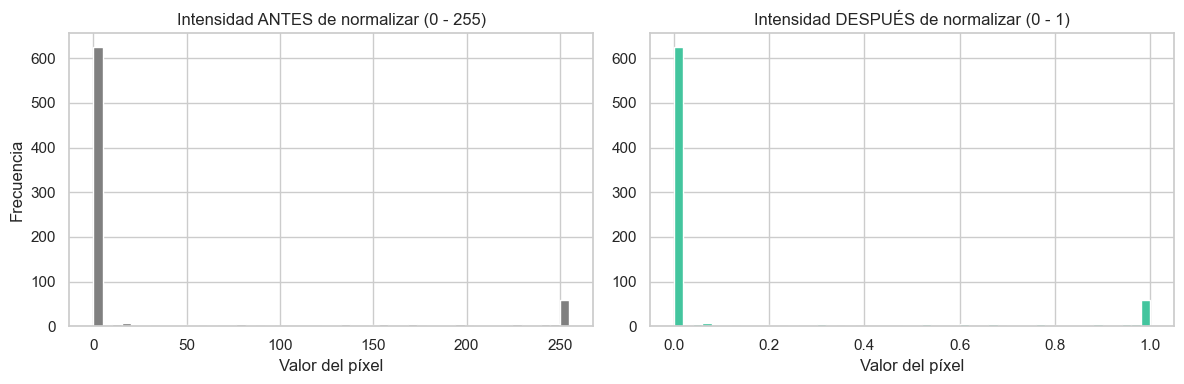

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma Antes
axes[0].hist(muestra_antes, bins=50, color='gray')
axes[0].set_title('Intensidad ANTES de normalizar (0 - 255)')
axes[0].set_xlabel('Valor del píxel')
axes[0].set_ylabel('Frecuencia')

# Histograma Después
axes[1].hist(muestra_despues, bins=50, color='#43C59E')
axes[1].set_title('Intensidad DESPUÉS de normalizar (0 - 1)')
axes[1].set_xlabel('Valor del píxel')

plt.tight_layout()
plt.show()

## One-Hot Encoding

In [6]:
def one_hot_encode(labels, num_classes=10):
    """Convierte etiquetas 0-9 en vectores one-hot de longitud 10."""
    return np.eye(num_classes)[labels]

y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)

print(f"y_train_onehot: {y_train_onehot.shape}") # (60000, 10)
print(f"y_test_onehot: {y_test_onehot.shape}") # (10000, 10)
N_CLASES = y_train_onehot.shape[1]

y_train_onehot: (60000, 10)
y_test_onehot: (10000, 10)


## Visualización

In [ ]:
# Visualizar una imagen individual
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

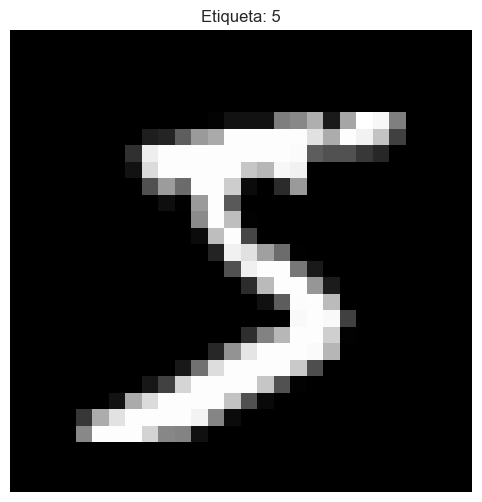

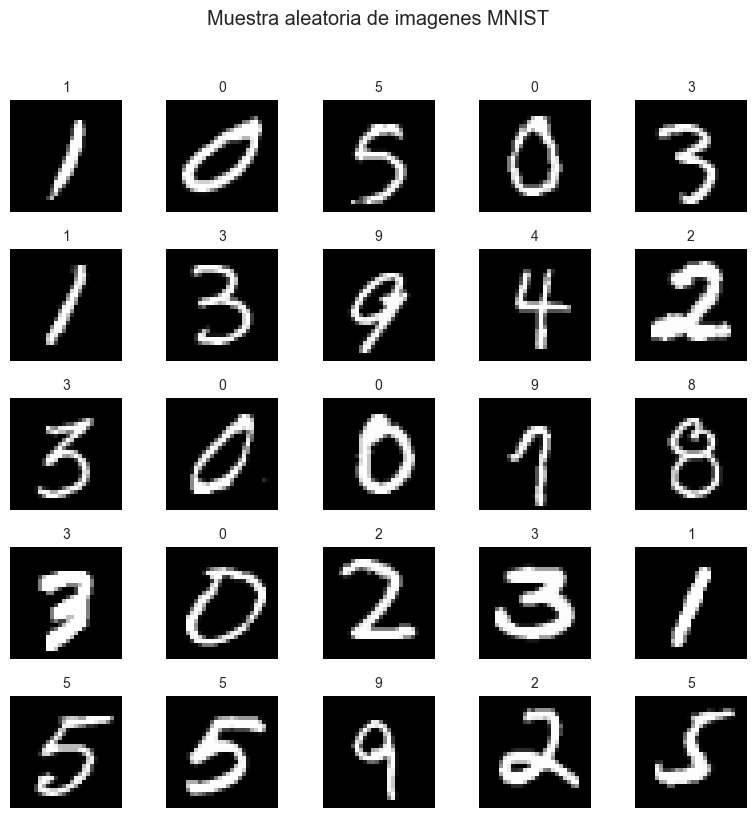

In [ ]:
# Visualizar una grilla de 5x5 imagenes aleatorias
indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

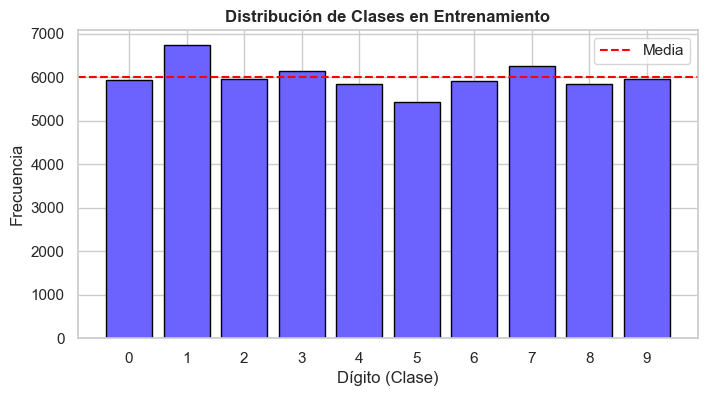

In [8]:
clases, frecuencias = np.unique(y_train_tensor, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(clases, frecuencias, color='#6C63FF', edgecolor='black')
plt.xticks(clases)
plt.title("Distribución de Clases en Entrenamiento", fontsize=12, fontweight='bold')
plt.xlabel("Dígito (Clase)")
plt.ylabel("Frecuencia")
plt.axhline(frecuencias.mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

In [9]:
# Conclusión impresa sobre el balance
desviacion_maxima = (frecuencias.max() - frecuencias.min()) / frecuencias.mean() * 100
print(f"El dataset está razonablemente balanceado. La variación máxima entre la clase más y menos frecuente es de solo {desviacion_maxima:.1f}%.")

El dataset está razonablemente balanceado. La variación máxima entre la clase más y menos frecuente es de solo 22.0%.


Al convertir y_train_raw a torch.long, le estamos diciendo a PyTorch explícitamente: "Estas son etiquetas enteras, no matrices one-hot". Esta es la forma profesional y recomendada de manejar clasificación multiclase en PyTorch, ya que ahorra el gasto de memoria de crear una matriz de ceros y unos para 60.000 ejemplos.

In [33]:
# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {y_train_onehot.shape}")
print(f"Forma aplanada: {y_train_tensor.shape}")

Forma original: (60000, 10)
Forma aplanada: torch.Size([60000])


In [34]:
def entrenar_pytorch_clasificacion(modelo, X_train, y_train, X_test, y_test,
                                    es_binario=True, epochs=200,
                                    batch_size=32, lr=1e-3,
                                    weight_decay=1e-4, patience=20):
    """
    Función de entrenamiento reutilizable para clasificación.
    El parámetro es_binario controla dos cosas que difieren entre ambos casos:
      1. El dtype del tensor de etiquetas (float32 para binaria, long para multiclase)
      2. La función de costo (BCEWithLogitsLoss vs. CrossEntropyLoss)
    Todo lo demás (el loop, el early stopping, los optimizadores) es idéntico.
    """

    # ── Conversión de numpy arrays a tensores PyTorch ────────────────────────
    # Los datos llegaron como numpy arrays desde scikit-learn.
    # PyTorch necesita su propio tipo: torch.Tensor.
    # dtype=torch.float32: 32 bits por número (estándar en Deep Learning).
    X_tr = torch.tensor(X_train, dtype=torch.float32)  # features de train
    X_te = torch.tensor(X_test,  dtype=torch.float32)  # features de test

    if es_binario:
        # Binaria: las etiquetas son 0 o 1 → float32 (BCE las necesita continuas)
        # ¿Por qué float y no int? BCEWithLogitsLoss opera con punto flotante.
        y_tr = torch.tensor(y_train, dtype=torch.float32)
        y_te = torch.tensor(y_test,  dtype=torch.float32)

        # BCEWithLogitsLoss = Sigmoid interna + BCE
        # Recibe logits crudos (sin Sigmoid aplicado antes)
        # y las etiquetas como floats en {0.0, 1.0}
        # ¿Por qué no BCELoss?
        # BCELoss requiere que ya hayas aplicado Sigmoid → numéricamente inestable
        # para logits muy grandes o muy pequeños (overflow en exp).
        # BCEWithLogitsLoss funde ambos en una operación más estable.
        criterio = nn.BCEWithLogitsLoss()

    else:
        # Multiclase: las etiquetas son índices enteros (0, 1, 2...)
        # dtype=torch.long: entero de 64 bits, el único dtype que acepta
        # CrossEntropyLoss para los targets.
        y_tr = torch.tensor(y_train, dtype=torch.long)
        y_te = torch.tensor(y_test,  dtype=torch.long)

        # CrossEntropyLoss = Softmax interna + CCE (Categorical Cross-Entropy)
        # Recibe logits crudos de forma (batch, N_clases)
        # y las etiquetas como enteros (índice de la clase correcta)
        # Internamente calcula log(softmax(logits)) de forma numéricamente estable
        criterio = nn.CrossEntropyLoss()

    # ── DataLoader: batching y shuffle automático ────────────────────────────
    # TensorDataset empaqueta X e y juntos; al iterar devuelve pares (X_batch, y_batch)
    # shuffle=True: en cada época los batches se forman aleatoriamente.
    #   Fundamental: si no shuffleamos, el modelo ve siempre los mismos grupos,
    #   lo que puede crear sesgos en el gradiente y dificultar la convergencia.
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    # ── Optimizador Adam ─────────────────────────────────────────────────────
    # optim.Adam(modelo.parameters(), ...):
    #   modelo.parameters(): iterador sobre todos los tensores W y b de la red
    #   lr: learning rate base (Adam lo ajusta por parámetro internamente)
    #   weight_decay: coeficiente de regularización L2 (penaliza pesos grandes)
    #     En cada actualización: w ← w·(1 - lr·weight_decay) - lr·grad
    #     El factor (1 - lr·weight_decay) < 1 encoge el peso en cada paso.
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # ── Variables de seguimiento del entrenamiento ───────────────────────────
    # historial: guardamos la pérdida en cada época para graficar al final
    historial = {'train_loss': [], 'test_loss': []}
    # mejor_loss: la menor pérdida de test vista hasta ahora
    mejor_loss  = float('inf')   # inf: cualquier pérdida real será menor
    # mejor_pesos: copia del state_dict cuando la pérdida de test fue mínima
    mejor_pesos = None
    # espera: contador de épocas sin mejora (para early stopping)
    espera      = 0

    print(f"\n Entrenando (PyTorch) | epochs={epochs} | batch={batch_size} | lr={lr}")

    for epoca in range(epochs):

        # ════════════════════════════════════════════
        #  FASE DE ENTRENAMIENTO
        # ════════════════════════════════════════════
        # modelo.train(): activa Dropout y BatchNorm en modo training.
        #   - Dropout apaga neuronas aleatoriamente
        #   - BatchNorm usa estadísticas del batch actual (no las acumuladas)
        modelo.train()
        train_loss = 0.0

        for Xb, yb in loader:
            # Xb: un batch de features, forma (batch_size, n_features)
            # yb: las etiquetas de ese batch, forma (batch_size,)

            # PASO 1 — Forward pass: calcular predicciones
            # modelo(Xb) llama implícitamente a modelo.forward(Xb)
            pred = modelo(Xb)   # logits, forma (batch_size,) o (batch_size, N)

            # PASO 2 — Calcular la pérdida del batch
            # criterio compara las predicciones con las etiquetas reales
            loss = criterio(pred, yb)

            # PASO 3 — Limpiar gradientes acumulados del paso anterior
            # PyTorch acumula gradientes por defecto (diseñado para RNNs/TBPTT).
            # Si no limpiamos, los gradientes de este batch se SUMAN a los del
            # anterior: la actualización sería con la suma de ambos, no solo del
            # batch actual. Eso corrompe el entrenamiento.
            optimizador.zero_grad()

            # PASO 4 — Backward pass: calcular ∂L/∂w para todos los parámetros
            # loss.backward() recorre el grafo computacional hacia atrás
            # (de la salida hacia la entrada) aplicando la Regla de la Cadena.
            # Al terminar, cada parámetro p tiene p.grad = ∂L/∂p.
            loss.backward()

            # PASO 5 — Actualizar pesos
            # optimizer.step() aplica: θ ← θ - lr · grad (con correcciones Adam)
            # Adam también actualiza sus vectores de estado m y v internamente.
            optimizador.step()

            # Acumulamos la pérdida para promediarla al final de la época
            # .item() convierte el tensor escalar a un float Python
            train_loss += loss.item()

        # Pérdida promedio sobre todos los batches de esta época
        train_loss /= len(loader)

        # ════════════════════════════════════════════
        #  FASE DE EVALUACIÓN (sin actualizar pesos)
        # ════════════════════════════════════════════
        # modelo.eval(): desactiva Dropout y cambia BatchNorm a estadísticas
        #   acumuladas durante training. La red es determinística en eval.
        modelo.eval()

        # torch.no_grad(): desactiva el cálculo del grafo computacional.
        #   En evaluación no necesitamos backward, así que no necesitamos
        #   el grafo. Desactivarlo ahorra ~50% de memoria y tiempo.
        with torch.no_grad():
            pred_test = modelo(X_te)                      # predicciones en test
            test_loss = criterio(pred_test, y_te).item()  # pérdida en test

        # Guardamos ambas pérdidas para graficar las curvas de aprendizaje
        historial['train_loss'].append(train_loss)
        historial['test_loss'].append(test_loss)

        # ════════════════════════════════════════════
        #  EARLY STOPPING
        # ════════════════════════════════════════════
        if test_loss < mejor_loss:
            # Nueva mejor pérdida de validación → guardamos este estado
            mejor_loss = test_loss

            # state_dict(): diccionario {nombre_capa: tensor_de_pesos}
            # .clone(): copia profunda del tensor (no una referencia)
            #   Sin clone, mejor_pesos apuntaría al mismo tensor en memoria,
            #   que seguirá cambiando en las épocas siguientes.
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0   # reiniciar contador de épocas sin mejora
        else:
            espera += 1  # una época más sin mejorar

        if (epoca + 1) % 30 == 0:
            print(f"   Época {epoca+1:4d} | Train: {train_loss:.4f} | "
                  f"Test: {test_loss:.4f} | Sin mejora: {espera}/{patience}")

        if espera >= patience:
            # patience épocas sin mejorar → detener y restaurar mejor estado
            print(f"\n   ⏹️  Early stopping en época {epoca+1} "
                  f"(mejor pérdida val: {mejor_loss:.4f})")
            break

    # Restaurar los pesos del mejor momento del entrenamiento
    # load_state_dict() carga el diccionario de pesos guardado anteriormente
    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
    return historial

In [35]:
def graficar_curvas(historial, titulo='Curvas de Entrenamiento', nombre_archivo=None):
    """Grafica train loss vs test loss a lo largo de las épocas."""
    epocas = range(1, len(historial['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # Gráfico 1: Curvas de pérdida en escala normal
    axes[0].plot(epocas, historial['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
    axes[0].plot(epocas, historial['test_loss'],  label='Test Loss', color='#e74c3c', linewidth=2, linestyle='--')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Pérdida (MSE)')
    axes[0].set_title('Pérdida por época')
    axes[0].legend()

    # Marcar el mínimo de test loss (punto de early stopping)
    mejor_epoca = np.argmin(historial['test_loss']) + 1
    mejor_loss  = min(historial['test_loss'])
    axes[0].axvline(mejor_epoca, color='green', linestyle=':', alpha=0.7, label=f'Mejor época: {mejor_epoca}')
    axes[0].scatter([mejor_epoca], [mejor_loss], color='green', zorder=5, s=80)
    axes[0].legend()

    # Gráfico 2: Diferencia (brecha de generalización)
    brecha = np.array(historial['test_loss']) - np.array(historial['train_loss'])
    axes[1].fill_between(epocas, 0, brecha, alpha=0.3, color='#e67e22' if brecha[-1] > 0.1 else '#2ecc71')
    axes[1].plot(epocas, brecha, color='#e67e22', linewidth=2)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='-')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Test Loss − Train Loss')
    axes[1].set_title('Brecha de generalización\n(cercana a 0 = sin overfitting)')

    plt.tight_layout()
    if nombre_archivo:
        plt.savefig(nombre_archivo, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"[Figura guardada: {nombre_archivo}]")
    print(f"\n   Interpretación:")
    print(f"   • Mejor época: {mejor_epoca}")
    print(f"   • Mínima Test Loss: {mejor_loss:.4f}")
    print(f"   • Brecha final: {brecha[-1]:.4f} "
          f"({'overfitting' if brecha[-1] > 0.2 else '✅ generalización OK'})")


  Arquitectura PyTorch (Multiclase):
ClasificacionMulticlaseNet_PyTorch(
  (red): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)
   Total de parámetros entrenables: 109,770

 Entrenando (PyTorch) | epochs=300 | batch=516 | lr=0.001


C:\Users\nicom\AppData\Local\Temp\ipykernel_13216\1804847262.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tr = torch.tensor(y_train, dtype=torch.long)
C:\Users\nicom\AppData\Local\Temp\ipykernel_13216\1804847262.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_te = torch.tensor(y_test,  dtype=torch.long)


   Época   30 | Train: 0.0626 | Test: 0.0662 | Sin mejora: 6/20

   ⏹️  Early stopping en época 59 (mejor pérdida val: 0.0612)


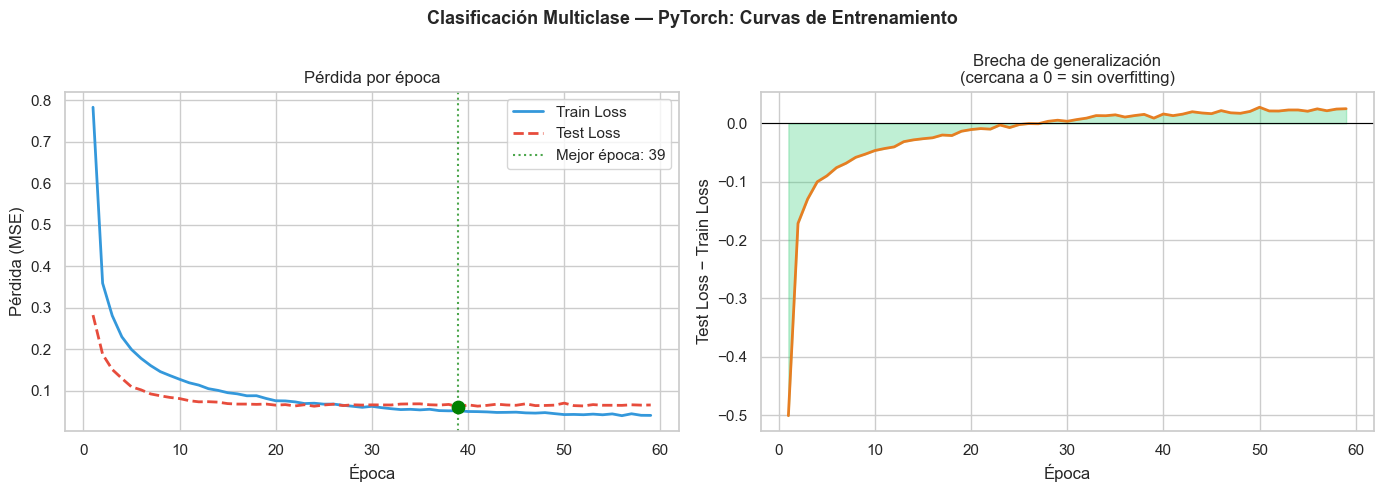

[Figura guardada: mc_02_curvas_pytorch.png]

   Interpretación:
   • Mejor época: 39
   • Mínima Test Loss: 0.0612
   • Brecha final: 0.0251 (✅ generalización OK)


In [36]:
class ClasificacionMulticlaseNet_PyTorch(nn.Module):
    def __init__(self, input_dim=int(X_train_flat.shape[1]), n_clases=N_CLASES, dropout_rate=0.3):
        super().__init__()
        self.red = nn.Sequential(

            # ── CAPA OCULTA 1: 30 → 128 ───────────────────────────────────
            # Más neuronas que en binaria porque el problema es más complejo.
            # Parámetros: 128×30 + 128 = 3.968
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # normaliza las 128 activaciones del batch
            nn.ReLU(),            # introduce no-linealidad
            nn.Dropout(dropout_rate),  # apaga el 30% aleatoriamente en training

            # ── CAPA OCULTA 2: 128 → 64 ───────────────────────────────────
            # Compresión progresiva: de 128 a 64 representaciones más abstractas.
            # Parámetros: 64×128 + 64 = 8.256
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # ── CAPA DE SALIDA: 64 → N_CLASES ─────────────────────────────
            # Produce un vector de 10 logits (z_0, z_1, z_2, z_3, z_4, ..).
            nn.Linear(64, n_clases)
        )

        # Inicialización He para todas las capas lineales
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: forma (batch_size, 30) → batch de artículos de noticias
        salida: forma (batch_size, 5) → 5 logits por artículo

        A diferencia de la red binaria que hacía .squeeze(1),
        aquí devolvemos el tensor 2D completo porque CrossEntropyLoss
        espera (batch_size, n_clases) como predicciones y (batch_size,)
        como etiquetas.
        """
        return self.red(x)   # logits, forma: (batch, n_clases)


# Instanciar
modelo_mc_pt = ClasificacionMulticlaseNet_PyTorch(784, N_CLASES, 0.3)
print(f"\n  Arquitectura PyTorch (Multiclase):")
print(modelo_mc_pt)
total_params_mc = sum(p.numel() for p in modelo_mc_pt.parameters() if p.requires_grad)
print(f"   Total de parámetros entrenables: {total_params_mc:,}")

# Entrenamiento
historial_mc_pt = entrenar_pytorch_clasificacion(
    modelo_mc_pt,
    X_train_norm, y_train_tensor,    
    X_test_norm,  y_test_tensor,
    es_binario=False,  # activa CrossEntropyLoss y dtype=long
    epochs=300, batch_size=516, lr=1e-3, weight_decay=1e-4, patience=20
)

graficar_curvas(historial_mc_pt, 'Clasificación Multiclase — PyTorch: Curvas de Entrenamiento', 'mc_02_curvas_pytorch.png')


 Evaluación PyTorch (Multiclase):
   Accuracy: 0.9827 (98.27%)

   Reporte por clase:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



C:\Users\nicom\AppData\Local\Temp\ipykernel_13216\2252202532.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


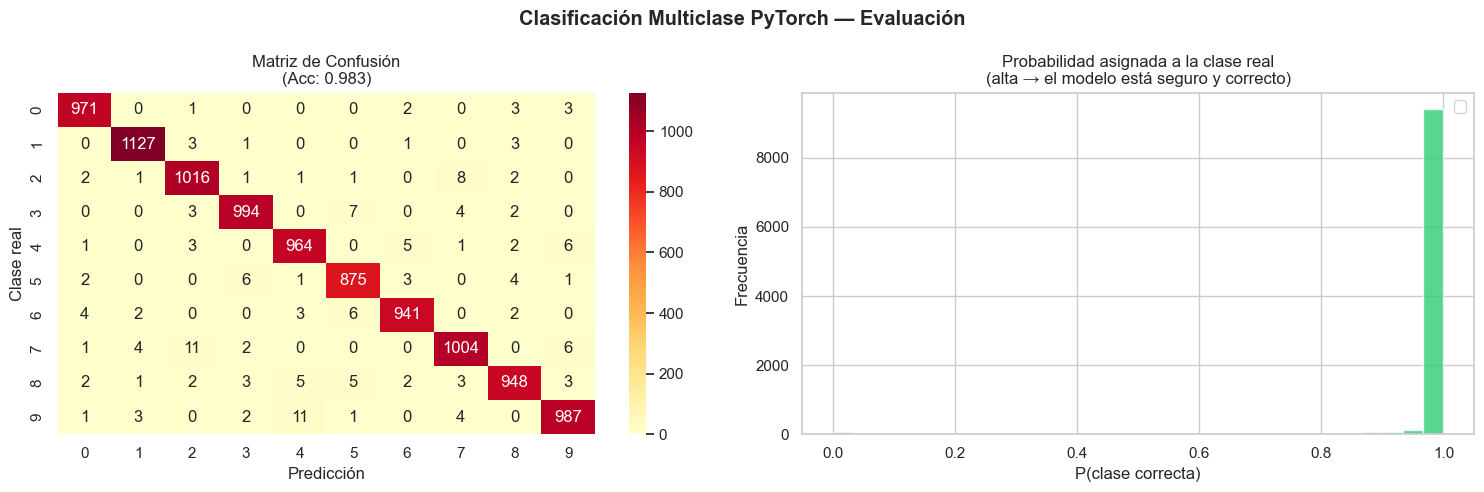

In [37]:
# ── Evaluación multiclase PyTorch ────────────────────────────────────────────
modelo_mc_pt.eval()
with torch.no_grad():
    # La red devuelve logits de forma (n_test, 5)
    logits_mc = modelo_mc_pt(torch.tensor(X_test_norm, dtype=torch.float32))

    # torch.softmax(logits, dim=1): aplica Softmax a lo largo de la dimensión
    # de las clases (dim=1). Para cada fila (ejemplo), normaliza los 5 logits
    # a una distribución de probabilidad que suma 1.
    # .numpy(): convierte a array de numpy para usar con sklearn
    probs_mc  = torch.softmax(logits_mc, dim=1).numpy()

    # logits_mc.argmax(dim=1): para cada fila, devuelve el índice del logit
    # mayor. Con Softmax monotónica, argmax(logits) = argmax(probabilidades).
    # No necesitamos aplicar Softmax para la decisión, solo para las probs.
    preds_mc  = logits_mc.argmax(dim=1).numpy()

acc_mc = accuracy_score(y_test_tensor, preds_mc)
print(f"\n Evaluación PyTorch (Multiclase):")
print(f"   Accuracy: {acc_mc:.4f} ({acc_mc*100:.2f}%)")
print(f"\n   Reporte por clase:")
# classification_report con target_names asigna nombres a los índices 0,1,2,3,4
print(classification_report(y_test_tensor, preds_mc))

# Matriz de confusión multiclase
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Clasificación Multiclase PyTorch — Evaluación', fontweight='bold')

cm_mc = confusion_matrix(y_test_tensor, preds_mc)
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='YlOrRd', xticklabels=[str(c) for c in range(N_CLASES)], yticklabels=range(0, 10), ax=axes[0])
axes[0].set_title(f'Matriz de Confusión\n(Acc: {acc_mc:.3f})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Clase real')

# Probabilidades de la clase correcta
probs_correctas = [probs_mc[i, y_test_tensor[i]] for i in range(len(y_test_tensor))]
axes[1].hist(probs_correctas, bins=30, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('P(clase correcta)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Probabilidad asignada a la clase real\n(alta → el modelo está seguro y correcto)')
axes[1].legend()

plt.tight_layout()
plt.savefig('mc_03_evaluacion_pytorch.png', dpi=120, bbox_inches='tight')
plt.show()